Post Lab Task 1: Classification on Titanic Dataset

Accuracy: 0.7653631284916201

Confusion Matrix:
 [[82 23]
 [19 55]]

Classification Report:

              precision    recall  f1-score   support

           0       0.81      0.78      0.80       105
           1       0.71      0.74      0.72        74

    accuracy                           0.77       179
   macro avg       0.76      0.76      0.76       179
weighted avg       0.77      0.77      0.77       179



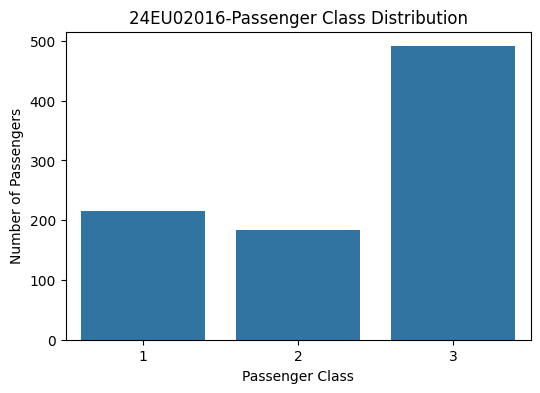

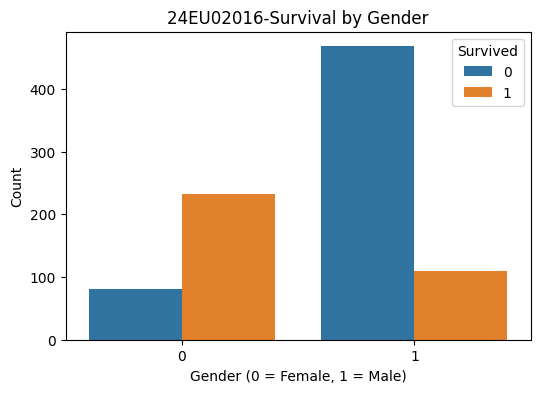

In [ ]:
# Import Libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Load Titanic Dataset
titanic = sns.load_dataset('titanic')

# Select required columns and create a copy
data = titanic[['survived', 'pclass', 'sex', 'age', 'fare', 'embarked']].copy()

# Handle Missing Values
data['age'] = data['age'].fillna(data['age'].median())
data['embarked'] = data['embarked'].fillna(data['embarked'].mode()[0])

# Encode Categorical Columns
le = LabelEncoder()
data['sex'] = le.fit_transform(data['sex'])
data['embarked'] = le.fit_transform(data['embarked'])

# Features and Target
X = data.drop('survived', axis=1)
y = data['survived']

# Split Dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# Train Decision Tree Model
model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:\n", cm)

# Classification Report
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))
# Passenger Class Distribution
plt.figure(figsize=(6,4))
sns.countplot(x='pclass', data=data)
plt.title("24EU02016-Passenger Class Distribution")
plt.xlabel("Passenger Class")
plt.ylabel("Number of Passengers")
plt.show()

# Survival based on Gender
plt.figure(figsize=(6,4))
sns.countplot(x='sex', hue='survived', data=data)

plt.title("24EU02016-Survival by Gender")
plt.xlabel("Gender (0 = Female, 1 = Male)")
plt.ylabel("Count")
plt.legend(title="Survived")
plt.show()

Post Lab Task 2: Regression on California Housing Dataset

Mean Absolute Error: 0.533200130495698
Mean Squared Error: 0.5558915986952422
Root Mean Squared Error: 0.7455813830127749
R2 Score: 0.5757877060324524


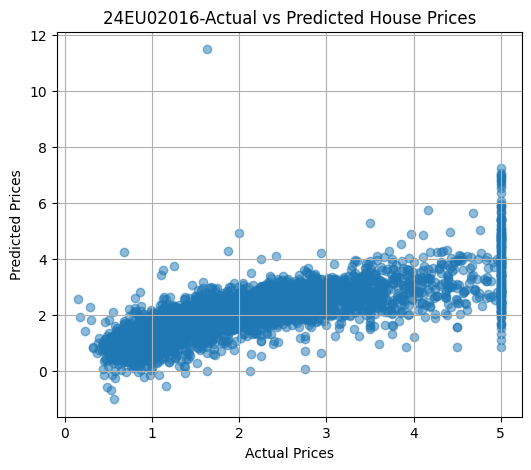

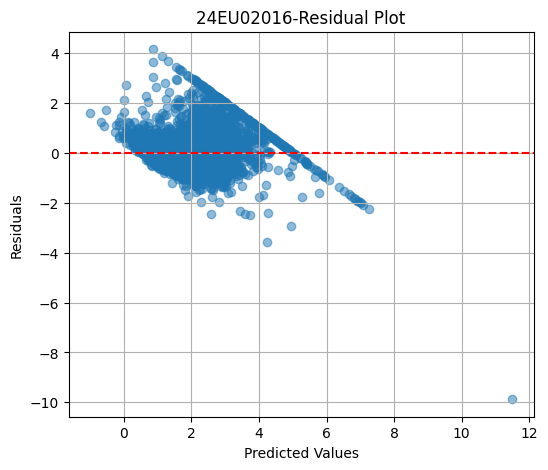

In [ ]:
# Import Libraries
import matplotlib.pyplot as plt
import numpy as np

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Load Dataset
housing = fetch_california_housing()

X = housing.data
y = housing.target

# Split Dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train Model
model = LinearRegression()
model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

# Evaluation
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error:", mae)
print("Mean Squared Error:", mse)
print("Root Mean Squared Error:", rmse)
print("R2 Score:", r2)

plt.figure(figsize=(6,5))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("24EU02016-Actual vs Predicted House Prices")
plt.grid(True)
plt.show()

plt.figure(figsize=(6,5))
plt.scatter(y_pred, y_test-y_pred, alpha=0.5)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("24EU02016-Residual Plot")
plt.grid(True)
plt.show()